# Preamble

In [1]:
import numpy as np
import scipy.integrate as itg
import scipy.linalg as spla
import matplotlib as mpl
import matplotlib.pyplot as plt
import mpl_toolkits.mplot3d as mplot3d
from cycler import cycler
import colorsys
import itertools
import timeit

plt.style.use("dark_background")
mpl.rcParams["axes.prop_cycle"] = cycler(color=mpl.color_sequences["Pastel1"])
mpl.rcParams["figure.facecolor"] = "564b3c"
mpl.rcParams["axes.facecolor"] = colorsys.hsv_to_rgb(141.4/360, .123, .447/2)
mpl.rcParams["axes.xmargin"] = 0.125       
mpl.rcParams["axes.ymargin"] = 0.125
mpl.rcParams["axes3d.xaxis.panecolor"] = (1.0, 0.5, 0.5, 0.0625)
mpl.rcParams["axes3d.yaxis.panecolor"] = (1.0, 0.5, 1.0, 0.0625)
mpl.rcParams["axes3d.zaxis.panecolor"] = (0.0, 0.5, 1.0, 0.0625)
mpl.rcParams["grid.color"] = (1.0, 1.0, 1.0, 0.125)
mpl.rcParams["figure.figsize"] = [9.6, 7.2]
mpl.rcParams["figure.dpi"] = 150
mpl.rcParams['text.usetex'] = True

log_scale_kwargs = dict(base=10)

# Scalar ODE for eigenvalues

Bernoulli differential equation: $y' = y - y^3.$ If $y_0 \in {0, \pm 1}$ then $y = y_0.$ Otherwise substitute $v := y^{-2},$ get
$$v' = -2y^{-3} y' = -2 y^{-3} (y - y^3) = 2(1-v).$$
Then
$$1-v = 1-y^{-2} = C\exp(-2t)$$
so
$$y = \pm(1-C\exp(-2t))^{-1/2}.$$
In terms of initial conditions
$$C = 1-y_0^{-2}.$$
Finally
$$y = \frac{\operatorname{sgn} y_0}{\sqrt{1-(1-y_0^{-2})\exp(-2t)}} = \frac{y_0}{\sqrt{1 + (1-y_0^2)(\exp(-2t)-1)}} := \frac{y_0}{\sqrt{\Delta(t, y_0)}}.$$
This expression is valid for $t > t_* = \frac{1}{2} \log \left( 1 - y_0^{-2} \right)$ when $|y_0| > 1.$ If $|y_0| < 1,$ it is valid for all $t.$ This is equivalent to checking if the determinant $\Delta(t, y_0) > 0.$ Since ODE is autonomous, all solutions for various $t_0$ can be gotten by simple shifts.

In [2]:
def fun(t, y):
    return y * (1.0 - y * y)


def y_exact(t, y0):
    if y0 in (0.0, 1.0, -1.0):
        return np.full_like(t, y0)
    determinant = 1.0 + (1.0 - y0 * y0) * np.expm1(-2.0 * t)
    return y0 * np.where(
        determinant > 0.0,
        np.reciprocal(np.sqrt(determinant)),
        np.full_like(t, np.inf),
    )

# Naive RK and Euler

The first method is explicit Euler, and we will take advantage of `scipy`'s existing infrastructure for solving IVPs. Butcher tableau notation from the Hairer, Nørsett, Wanner book:
$$
\def\arraystretch{1.5}\begin{array}{c|c}
   C & A \\ \hline
     & B^T \\
\end{array} =
\def\arraystretch{1.0}\begin{array}{c|c}
   0      &  \\
   c_2    & a_{21} \\
   \vdots & \vdots & \ddots \\
   c_S    & a_{S1}   & \cdots & a_{S,S-1} \\
   \hline
          & b_1 & \cdots & b_{S-1} & b_S \\
\end{array}
$$
where for each stage $s = 1, \ldots, S,$ we find entry of $K = (k_1 \quad \cdots \quad k_S \quad k_{S+1})^T,$
$$
k_s = f\left(t_0 + c_s h\ ,\ y_0 + h \sum_{i=1}^{s-1} a_{si} k_i \right),
$$
and the result of the step is $y_1 = y_0 + h B^T K.$ The next slope $k_{S+1} = f(t_0 + h, y_1)$ is also computed.

In [3]:
from scipy.integrate._ivp.rk import RungeKutta, rk_step


class RK11(RungeKutta):
    order = 1
    error_estimator_order = 1
    n_stages = 1
    C = np.array([0.0])
    A = np.array([[0.0]])
    B = np.array([1.0])
    E = np.array([-0.5, 0.5])
    P = np.array([[1.0, 1, -1], [0, -1, 1]])

In [4]:
class NaiveRungeKutta(RungeKutta):
    def __init__(
        self,
        fun,
        t0,
        y0,
        t_bound,
        num_steps=50,
        rtol=1e-3,
        atol=1e-6,
        vectorized=False,
        **extraneous
    ):
        itg._ivp.common.warn_extraneous(extraneous)

        self.num_steps = num_steps
        self.steps_taken = 0
        self.step_ts = np.linspace(t0, t_bound, num_steps + 1)
        max_step = np.max(np.abs(self.step_ts[1:] - self.step_ts[:-1]))
        first_step = np.abs(self.step_ts[1] - self.step_ts[0])

        super().__init__(
            fun,
            t0,
            y0,
            t_bound,
            max_step=max_step,
            rtol=rtol,
            atol=atol,
            vectorized=vectorized,
            first_step=first_step,
        )

    def _step_impl(self):
        t = self.t
        y = self.y

        rtol = self.rtol
        atol = self.atol

        min_step = 10 * np.abs(np.nextafter(t, self.direction * np.inf) - t)

        t_new = self.step_ts[self.steps_taken + 1]
        h = t_new - t
        h_abs = np.abs(h)

        if h_abs < min_step:
            return False, self.TOO_SMALL_STEP

        y_new, f_new = rk_step(
            self.fun, t, y, self.f, h, self.A, self.B, self.C, self.K
        )
        scale = atol + np.maximum(np.abs(y), np.abs(y_new)) * rtol
        error_norm = self._estimate_error_norm(self.K, h, scale)

        self.h_previous = h
        self.y_old = y

        self.t = t_new
        self.y = y_new

        self.h_abs = h_abs
        self.f = f_new
        self.steps_taken += 1

        return True, None


class NaiveRK11(NaiveRungeKutta, RK11):
    pass

class NaiveRK23(NaiveRungeKutta, itg.RK23):
    pass

class NaiveRK45(NaiveRungeKutta, itg.RK45):
    pass

# Matrix differential equations

In [5]:
def make_polar_factor_flow_fun(out_dim):
    def polar_factor_flow_fun(_t, vecX):
        X = np.reshape(vecX, shape=(out_dim, -1))
        XTX = X.T @ X
        return np.reshape(X @ (np.eye(*np.shape(XTX)) - XTX), shape=(-1,))

    return polar_factor_flow_fun


def make_polar_factor_flow_jac(out_dim):
    def polar_factor_flow_jac(_t, vecX):
        X = np.reshape(vecX, shape=(out_dim, -1))
        n, m = X.shape
        dac_dbd = np.multiply.outer(np.eye(n), np.eye(m))
        dbd_Xaj_Xcj = np.multiply.outer(np.eye(m), X @ X.T)
        dac_Xkb_Xkd = np.multiply.outer(np.eye(n), X.T @ X)
        Xad_Xcb = np.multiply.outer(X, X)

        return (
            np.transpose(dac_dbd, (0, 2, 1, 3))
            - np.transpose(dbd_Xaj_Xcj, (2, 0, 3, 1))
            - np.transpose(dac_Xkb_Xkd, (0, 2, 1, 3))
            - np.transpose(Xad_Xcb, (0, 3, 2, 1))
        ).reshape((n * m, n * m))

    return polar_factor_flow_jac


def polar_factor_flow_exact_helped(t, sv0s, U, V):
    Sigma = np.zeros((U.shape[1], V.shape[1]))
    np.fill_diagonal(Sigma, [y_exact(t, sv0) for sv0 in sv0s])
    return U @ Sigma @ V.T

# Parameter choice

In [6]:
def random_hypersphere(rng: np.random.Generator, dim: int):
    # https://dl.acm.org/doi/epdf/10.1145/377939.377946
    normpt = 0.0
    while normpt == 0.0:
        pt = rng.standard_normal(dim + 1)
        normpt = np.linalg.vector_norm(pt)
    pt /= normpt
    return pt

Matrix exponential of skew symmetric matrices are special orthogonal matrices thanks to 2-forms generating rotations.

In [7]:
def random_SO(rng: np.random.Generator, n: int):
    mex = np.zeros((n, n))

    rot = (np.pi - rng.uniform(-np.pi, np.pi)) * random_hypersphere(
        rng, n * (n - 1) // 2 - 1
    )

    for i in range(n):
        for j in range(i + 1, n):
            entry = rot[j - 1 + i * (2 * n - i - 3) // 2]
            mex[i, j] = entry
            mex[j, i] = -entry

    return spla.expm(mex)


def random_O(rng: np.random.Generator, n: int):
    U = random_SO(rng, n)
    if n > 0 and rng.integers(0, 2) == 1:
        U[:, 0] *= -1.0
    return U

Choose an initial value:

In [8]:
rng = np.random.default_rng(0x666666)

out_dim = 4
in_dim = 3
U = random_O(rng, out_dim)
sv0s = rng.uniform(0.0, 2.0, np.minimum(in_dim, out_dim))
V = random_O(rng, in_dim)
U, sv0s, V
Sigma0 = np.zeros((out_dim, in_dim))
np.fill_diagonal(Sigma0, sv0s)
X0 = U @ Sigma0 @ V.T

polar_factor_flow_fun = make_polar_factor_flow_fun(out_dim)
polar_factor_flow_jac = make_polar_factor_flow_jac(out_dim)

t_bounds = (0.0, 2.0)

# Fun lil' transformation sequence

In [ ]:
fig: plt.Figure = plt.figure(figsize=14.4 * np.array([1.0, 3.0 / 9]))
axd = fig.subplot_mosaic(
    """
AA..CC....
AABBCCDD.E
..BB..DD.E
""",
    width_ratios=(1, 1, 1, 1, 1, 1, 1, 1, 0.125, 0.125),
    subplot_kw=dict(
        axes_class=mplot3d.Axes3D,
        facecolor="none",
    ),
    per_subplot_kw=dict(E=dict(axes_class=None)),
)

rng = np.random.default_rng(0xABAD5EED)
samples = np.array(
    [
        np.array([1.0 if rng.integers(0, 2) else -1.0, *rng.uniform(-1.0, 1.0, 2)])[
            rng.permutation(3)
        ]
        for _ in range(666)
    ]
)
cmap = mpl.colormaps["BrBG"]

for ax_name in "ABCD":
    ax = axd[ax_name]
    ax.set_proj_type("ortho")
    ax.set_aspect("equal")
    ax.set_xlim(-2.0, 2.0)
    ax.set_ylim(-2.0, 2.0)
    ax.set_zlim(-2.0, 2.0)

points = samples.T
size = np.exp2(-1)
axd["A"].scatter(*points[:3], s=size, c=cmap(0.5))
points = V.T @ points
axd["B"].scatter(*points[:3], s=size, c=cmap(0.5))
points = Sigma0 @ points
axd["C"].scatter(*points[:3], s=size, c=cmap(0.5 + 0.25 * points[3]))
points = U @ points
scatter = axd["D"].scatter(*points[:3], s=size, c=cmap(0.5 + 0.25 * points[3]))
norm = plt.Normalize(-2.0, 2.0)
fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), axd["E"])

SyntaxError: invalid syntax. Perhaps you forgot a comma? (2972845188.py, line 8)

# Graph of Flow Lines and Euler Polygons

This is just bespoke tbh

In [10]:
def plot_flow_lines(ax: plt.Axes, num_lines, t_resolution=129, **kwargs):
    t_left, t_right = ax.get_xlim()

    ts = np.linspace(t_left, t_right, t_resolution)
    t0s = np.linspace(t_left, t_right, num_lines + 2)[1:-1]
    s0s = (t0s - t_left) / (t_right - t_left)

    y_bottom, y_top = ax.get_ylim()
    plot_kwargs = dict(linewidth=0.125, zorder=-1)
    plot_kwargs.update(kwargs or {})

    if y_bottom < -1.0:
        for t0, s0 in zip(t0s, s0s):
            y0 = -1.0 - (-1.0 - y_bottom) * s0
            ye = y_exact(ts - t0, y0)
            ax.plot(ts, ye, **plot_kwargs)

    if -1.0 < y_top or y_bottom < 0.0:
        for t0, s0 in zip(t0s, s0s):
            y0 = -1.0 + s0
            ye = y_exact(ts - t0, y0)
            ax.plot(ts, ye, **plot_kwargs)

    if 0.0 < y_top or y_bottom < 1.0:
        for t0, s0 in zip(t0s, s0s):
            y0 = 1.0 - s0
            ye = y_exact(ts - t0, y0)
            ax.plot(ts, ye, **plot_kwargs)

    if 1.0 < y_top:
        for t0, s0 in zip(t0s, s0s):
            y0 = 1.0 + (y_top - 1.0) * s0
            ye = y_exact(ts - t0, y0)
            ax.plot(ts, ye, **plot_kwargs)


def plot_polygon_of_soln_svs(
    ax: plt.Axes,
    soln: itg.OdeSolution,
    U,
    V,
    plot_args_getter=lambda i: dict(color=f"C{i}", marker=".", linestyle="-"),
    should_plot_exact=True,
    exact_args_getter=lambda i: dict(color=f"C{i}", linestyle=":", linewidth=1.0),
    exact_t_resolution=129,
):

    soln_svss = np.diagonal(
        U.T @ soln.y.T.reshape((soln.y.shape[1], *X0.shape)) @ V,
        axis1=1,
        axis2=2,
    ).T

    for i, soln_svs in enumerate(soln_svss):
        ax.plot(soln.t, soln_svs, **plot_args_getter(i))

    if should_plot_exact:
        # ax.set_autoscale_on(False)
        t_left = soln.t[0]
        t_right = soln.t[-1]
        ts = np.linspace(t_left, t_right, exact_t_resolution)
        for i, soln_svs in enumerate(soln_svss):
            ax.plot(ts, y_exact(ts, soln_svs[0]), **exact_args_getter(i))

First a graph of flow lines alongside a slope field strip

/tmp/ipykernel_16434/1660277819.py:11: RuntimeWarning: invalid value encountered in sqrt
  np.reciprocal(np.sqrt(determinant)),


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


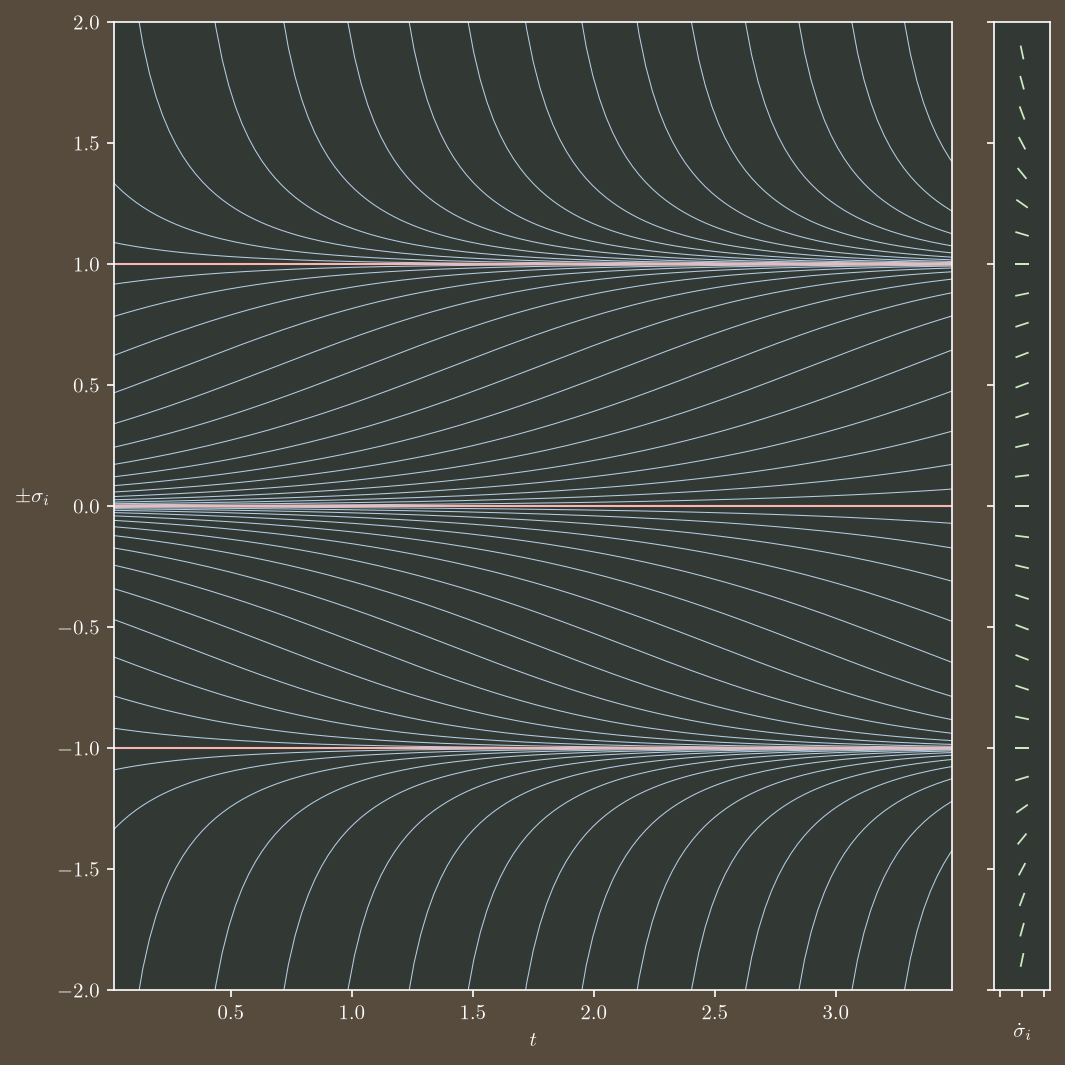

In [11]:
fig: plt.Figure
ax_flow: plt.Axes
ax_strip: plt.Axes
fig, (ax_flow, ax_strip) = plt.subplots(
    1, 2, figsize=plt.figaspect(1), width_ratios=(15, 1), sharey=True
)
fig.set_tight_layout(True)

ax_flow.set_xlabel("$t$")
ax_flow.set_ylabel("$\\pm\\sigma_i$", labelpad=12, rotation=0)
ax_flow.set_xlim(0.0, 3.5)
ax_flow.set_ylim(-2.0, 2.0)
ax_flow.set_aspect("equal", adjustable="datalim")
plot_flow_lines(ax_flow, 16, linewidth=0.5, color="C1")

ax_flow.axhline(-1.0, linewidth=1.0, color="C0")
ax_flow.axhline(0.0, linewidth=1.0, color="C0")
ax_flow.axhline(1.0, linewidth=1.0, color="C0")

ax_strip.set_xlabel("$\\dot{\\sigma}_i$", labelpad=12, rotation=0)
ax_strip.tick_params(labelbottom=False, which="both")

sigmas = np.linspace(*ax_flow.get_ylim(), 33)[1:-1]
rise = fun(0.0, sigmas)
run = np.ones_like(sigmas)
norms = np.linalg.vector_norm(np.array([run, rise]), axis=0)
ax_strip.quiver(
    np.zeros_like(sigmas),
    sigmas,
    run / norms,
    rise / norms,
    scale=np.exp2(2.0),
    width=np.exp2(-5.0),
    headlength=0,
    headaxislength=0,
    headwidth=0,
    pivot="middle",
    color="C2",
)

# Doing a bit more error analysis

fucking graphs

/tmp/ipykernel_16434/1660277819.py:11: RuntimeWarning: invalid value encountered in sqrt
  np.reciprocal(np.sqrt(determinant)),


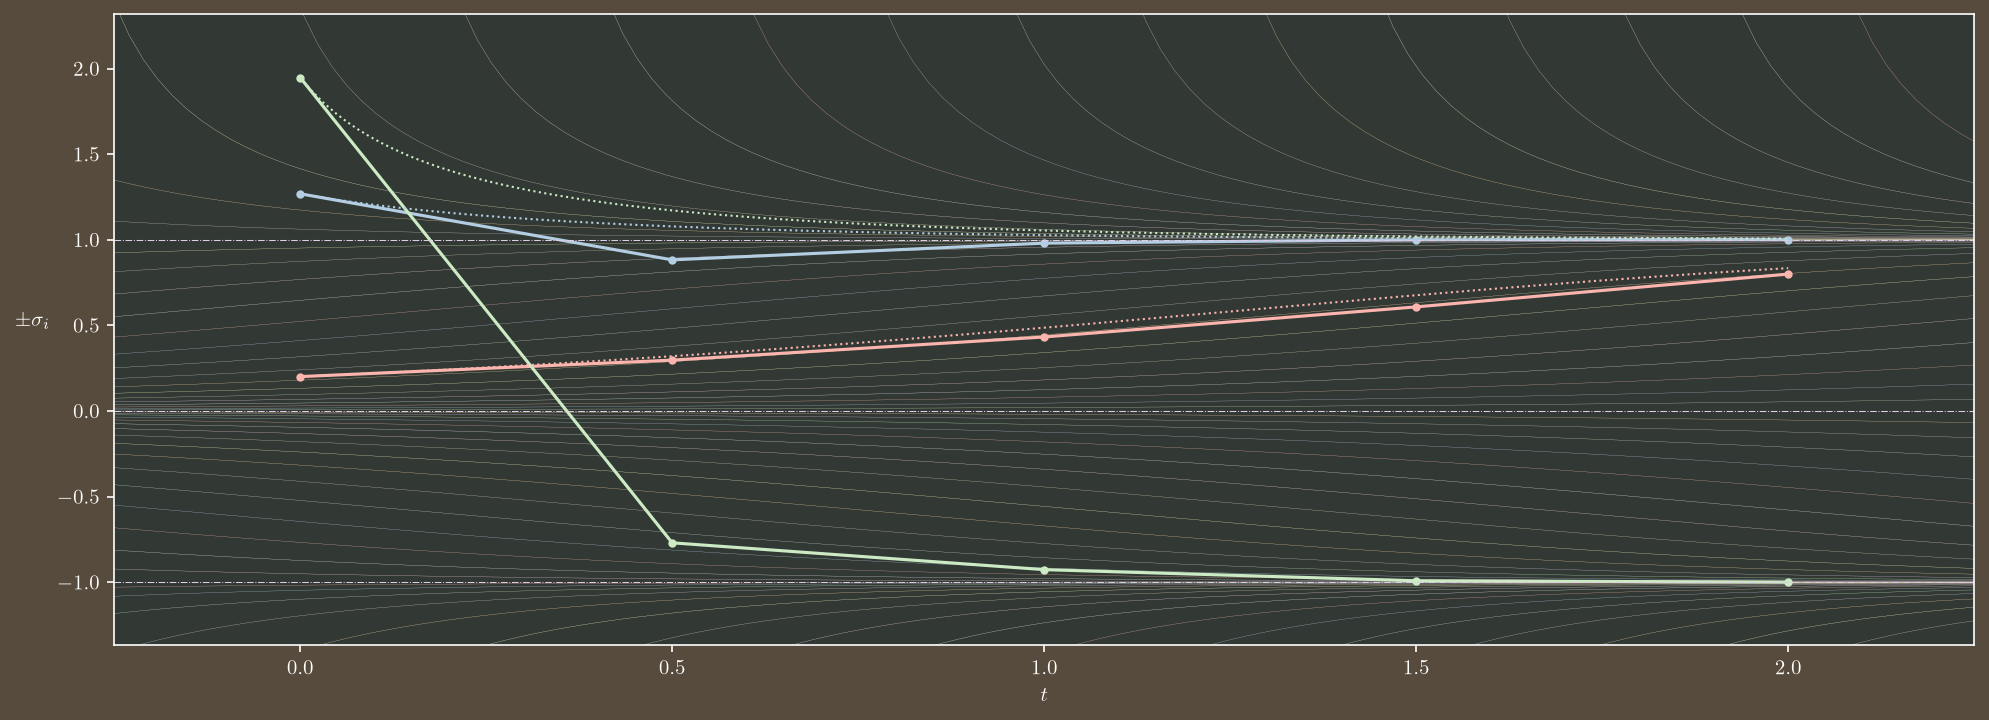

In [12]:
soln = itg.solve_ivp(
    polar_factor_flow_fun, t_bounds, np.ravel(X0), method=NaiveRK11, num_steps=4
)

fig: plt.Figure = plt.figure(figsize=plt.figaspect(415 / 1216))
ax: plt.Axes = fig.add_subplot()

ax.set_xlabel("$t$")
ax.set_ylabel("$\\pm\\sigma_i$", labelpad=12, rotation=0)

plot_polygon_of_soln_svs(ax, soln, U, V)

# ax.set_autoscale_on(False) # I want to do this but it seems buggy???
ax.set_xlim(*ax.get_xlim())
ax.set_ylim(*ax.get_ylim())
plot_flow_lines(ax, 16)

ax.axhline(-1.0, linewidth=0.5, linestyle="-.", color="C3")
ax.axhline(0.0, linewidth=0.5, linestyle="-.", color="C3")
ax.axhline(1.0, linewidth=0.5, linestyle="-.", color="C3")

plt.show()

Do an error analysis and put it in a data structure

In [13]:
from collections import namedtuple

ErrorAnalysisResult = namedtuple(
    "ErrorAnalysisResult",
    [
        "solver_kwargs_list",
        "exact_sol_fn",
        "avg_step_sizes",
        "global_errors",
        "avg_local_errors",
        "step_size_seqs",
        "local_error_curves",
        "error_lower_bound",
        "solns",
    ],
)


def do_error_analysis(solver_kwargs_list, exact_sol_fn, norm_fn):
    num_times_to_solve = len(solver_kwargs_list)
    avg_step_sizes = np.empty(num_times_to_solve)
    global_errors = np.empty(num_times_to_solve)
    avg_local_errors = np.empty(num_times_to_solve)
    step_size_seqs = []
    local_error_curves = []
    solns = []

    error_lower_bound = np.exp2(-36)  # TODO: calc this

    for i, solver_kwargs in enumerate(solver_kwargs_list):
        soln = itg.solve_ivp(**solver_kwargs)
        if "atol" in solver_kwargs:
            # make first step informed
            step_size_seq = soln.t[1:] - soln.t[:-1]
            solver_kwargs = dict(
                **solver_kwargs,
                first_step=(soln.t[-1] - soln.t[0]) / (step_size_seq.shape[0])
            )
            soln = itg.solve_ivp(**solver_kwargs)
        t0 = soln.t[0]
        y0 = soln.y.T[0]
        tf = soln.t[-1]
        approx_yf = soln.y.T[-1]
        exact_yf = exact_sol_fn(t0, y0, tf)

        global_error = norm_fn(exact_yf - approx_yf)

        step_size_seq = soln.t[1:] - soln.t[:-1]
        local_error_curve = np.empty_like(step_size_seq)

        for k in range(len(step_size_seq)):
            tk = soln.t[k]
            approx_yk = soln.y.T[k]
            tkp1 = soln.t[k + 1]
            approx_ykp1 = soln.y.T[k + 1]
            extend_ykp1 = exact_sol_fn(tk, approx_yk, tkp1)
            local_error_curve[k] = norm_fn(extend_ykp1 - approx_ykp1)

        avg_step_sizes[i] = (tf - t0) / len(step_size_seq)
        global_errors[i] = global_error
        avg_local_errors[i] = np.average(local_error_curve, weights=step_size_seq)
        step_size_seqs.append(step_size_seq)
        local_error_curves.append(local_error_curve)
        solns.append(soln)

    return ErrorAnalysisResult(
        solver_kwargs_list=solver_kwargs_list,
        exact_sol_fn=exact_sol_fn,
        avg_step_sizes=avg_step_sizes,
        global_errors=global_errors,
        avg_local_errors=avg_local_errors,
        step_size_seqs=step_size_seqs,
        local_error_curves=local_error_curves,
        error_lower_bound=error_lower_bound,
        solns=solns,
    )

For this specific problem, make a couple of adaptors:

In [14]:
def pff_exact_sol_fn(t0, y0, t):
    X0 = np.reshape(y0, (out_dim, in_dim))
    X = polar_factor_flow_exact_helped(t - t0, np.diagonal(U.T @ X0 @ V), U, V)
    return np.ravel(X)


def pff_norm_fn(dy):
    dX = np.reshape(dy, (out_dim, in_dim))
    return np.linalg.matrix_norm(dX)

Do all of it now.

In [15]:
runs_per_method = 6
fixed_step_kwargs_list = [
    dict(
        fun=polar_factor_flow_fun,
        t_span=t_bounds,
        y0=np.ravel(X0),
        num_steps=(1 << (2 * i)) * 4,
    )
    for i in range(runs_per_method)
]
adaptive_kwargs_list = [
    dict(
        fun=polar_factor_flow_fun,
        t_span=t_bounds,
        y0=np.ravel(X0),
        rtol=0.0,
        atol=np.exp2(-6 * i - 4),
    )
    for i in range(runs_per_method)
]


def do_error_analysis_with_method(method, kwargs_list):
    return do_error_analysis(
        [
            dict(
                **kwargs,
                method=method,
            )
            for kwargs in kwargs_list
        ],
        pff_exact_sol_fn,
        pff_norm_fn,
    )


error_analyses = {
    method.__name__: do_error_analysis_with_method(method, kwargs_list)
    for method, kwargs_list in itertools.chain(
        (
            (method, fixed_step_kwargs_list)
            for method in (NaiveRK11, NaiveRK23, NaiveRK45)
        ),
        (
            (method, adaptive_kwargs_list)
            for method in (RK11, itg.RK23, itg.RK45, itg.Radau, itg.BDF, itg.LSODA)
        ),
    )
}
(
    naive_rk11_error_analysis_result,
    naive_rk23_error_analysis_result,
    naive_rk45_error_analysis_result,
    rk11_error_analysis_result,
    rk23_error_analysis_result,
    rk45_error_analysis_result,
    radau_error_analysis_result,
    *_,
) = error_analyses.values()

/tmp/ipykernel_16434/3961084032.py:5: RuntimeWarning: overflow encountered in matmul
  return np.reshape(X @ (np.eye(*np.shape(XTX)) - XTX), shape=(-1,))
/home/hua/code/Team17/.venv/lib/python3.14/site-packages/scipy/integrate/_ivp/rk.py:63: RuntimeWarning: invalid value encountered in dot
  dy = np.dot(K[:s].T, a[:s]) * h
/home/hua/code/Team17/.venv/lib/python3.14/site-packages/scipy/integrate/_ivp/ivp.py:626: UserWarning: At least one element of `rtol` is too small. Setting `rtol = np.maximum(rtol, 2.220446049250313e-14)`.
  solver = method(fun, t0, y0, tf, vectorized=vectorized, **options)
/home/hua/code/Team17/.venv/lib/python3.14/site-packages/scipy/integrate/_ivp/radau.py:315: RuntimeWarning: divide by zero encountered in scalar divide
  self.newton_tol = max(10 * EPS / rtol, min(0.03, rtol ** 0.5))
/home/hua/code/Team17/.venv/lib/python3.14/site-packages/scipy/integrate/_ivp/bdf.py:217: RuntimeWarning: divide by zero encountered in scalar divide
  self.newton_tol = max(10 * EPS 

# The three projection graphs way instead of that 3D nonsense

already did the analysis

In [23]:
from mpl_toolkits.axisartist.parasite_axes import HostAxes


def make_error_analysis_figure(
    result, cmap, figkwargs=dict(figsize=7.2 * np.array([16.0 / 9.0, 1.0]))
):
    fig: plt.Figure = plt.figure(**figkwargs)
    fig.set_constrained_layout(True)

    ax_eigen = fig.add_subplot(221)
    ax_fevals = fig.add_subplot(222)
    ax_lerror = fig.add_subplot(223)
    ax_errsum: HostAxes = fig.add_subplot(224, axes_class=HostAxes)
    twin_errsum_lin = ax_errsum.get_aux_axes(
        viewlim_mode=None, axes_class=mpl.axes.Axes
    )
    ax_eigen.sharex(ax_lerror)
    ax_errsum.sharey(ax_lerror)
    ax_errsum.sharex(ax_fevals)

    ax_eigen.set_xlabel("$t$")
    ax_eigen.xaxis.set_label_position("top")
    ax_eigen.set_ylabel("$\\pm\\sigma$", labelpad=12, rotation=0)
    ax_eigen.tick_params(labeltop=True)
    ax_eigen.tick_params(top=True, labelbottom=False, which="both")

    ax_lerror.set_xlabel("$t$")
    ax_lerror.set_ylabel("$\\left\\Vert E_L \\right\\Vert$", labelpad=12, rotation=0)
    ax_lerror.set_yscale("log", **log_scale_kwargs)
    ax_lerror.tick_params(top=True, right=True, which="both")

    ax_errsum.set_xlabel("$h$")
    ax_errsum.set_xscale("log", **log_scale_kwargs)
    ax_errsum.set_ylabel("$\\left\\Vert E \\right\\Vert$", labelpad=12)
    ax_errsum.axis["left"].toggle(ticks=True, ticklabels=False, label=False)
    ax_errsum.axis["right"].toggle(all=True)
    ax_errsum.axis["right"].label.set_pad(12)
    ax_errsum.axis["right"].label._text_follow_ref_angle = False
    ax_errsum.axis["bottom"].minor_ticklabels.set_visible(False)

    ax_fevals.set_xlabel("$h$")
    ax_fevals.xaxis.set_label_position("top")
    ax_fevals.set_ylabel("$n_{\\mathrm{fev}}$", labelpad=12, rotation=0)
    ax_fevals.set_yscale("log", **log_scale_kwargs)
    ax_fevals.yaxis.set_label_position("right")
    ax_fevals.tick_params(labeltop=True, labelright=True)
    ax_fevals.tick_params(
        top=True,
        labelbottom=False,
        left=False,
        right=True,
        which="both",
        labelleft=False,
    )

    ts = np.linspace(*t_bounds, 129)

    num_solns = len(result.solns)
    colors = np.array(
        [cmap(1.0 - i / ((num_solns - 1) or 1)) for i in range(num_solns)]
    )
    for i in range(num_solns):
        soln = result.solns[i]
        color = colors[i]
        step_size_seq = result.step_size_seqs[i]
        local_error_curve = result.local_error_curves[i]

        plot_polygon_of_soln_svs(
            ax_eigen,
            soln,
            U,
            V,
            plot_args_getter=lambda k: dict(
                color=color,
                linewidth=0.5,
                fillstyle="none",
                marker=("x", "+", "o")[k],
                markersize=3,
                zorder=-i,
            ),
            should_plot_exact=False,
        )

        ax_lerror.step(
            soln.t[:-1],
            np.concat((local_error_curve[:1], local_error_curve[:-1])),
            linewidth=1.0,
            color=color,
            label="$\\left\\Vert E_L \\right\\Vert$" if i == 0 else None,
        )

    # ax.set_autoscale_on(False) # I want to do this but it seems buggy???
    ax_eigen.set_xlim(*ax_eigen.get_xlim())
    ax_eigen.set_ylim(*ax_eigen.get_ylim())
    plot_flow_lines(ax_eigen, 17)

    twin_errsum_lin.violinplot(
        [np.log2(curve[:-1]) for curve in result.local_error_curves],
        np.log2(result.avg_step_sizes),
        linecolor=colors,
        facecolor=colors * np.array([1.0, 1.0, 1.0, 0.25]),
    )
    ax_errsum.set_xlim(tuple(np.exp2(bound) for bound in twin_errsum_lin.get_xlim()))

    ax_errsum.scatter(
        result.avg_step_sizes,
        result.avg_local_errors,
        marker=mpl.markers.MarkerStyle("o", fillstyle="none"),
        c=np.clip(colors, 0.0, 1.0),
        label="$\\overline{\\left\\Vert E_L \\right\\Vert}$",
    )
    ax_errsum.scatter(
        result.avg_step_sizes,
        result.global_errors,
        marker="x",
        c=colors,
        label="$\\left\\Vert E_G \\right\\Vert$",
    )

    ax_fevals.scatter(
        result.avg_step_sizes,
        [soln.nfev for soln in result.solns],
        marker="D",
        c=colors,
    )

/tmp/ipykernel_16434/1660277819.py:11: RuntimeWarning: invalid value encountered in sqrt
  np.reciprocal(np.sqrt(determinant)),


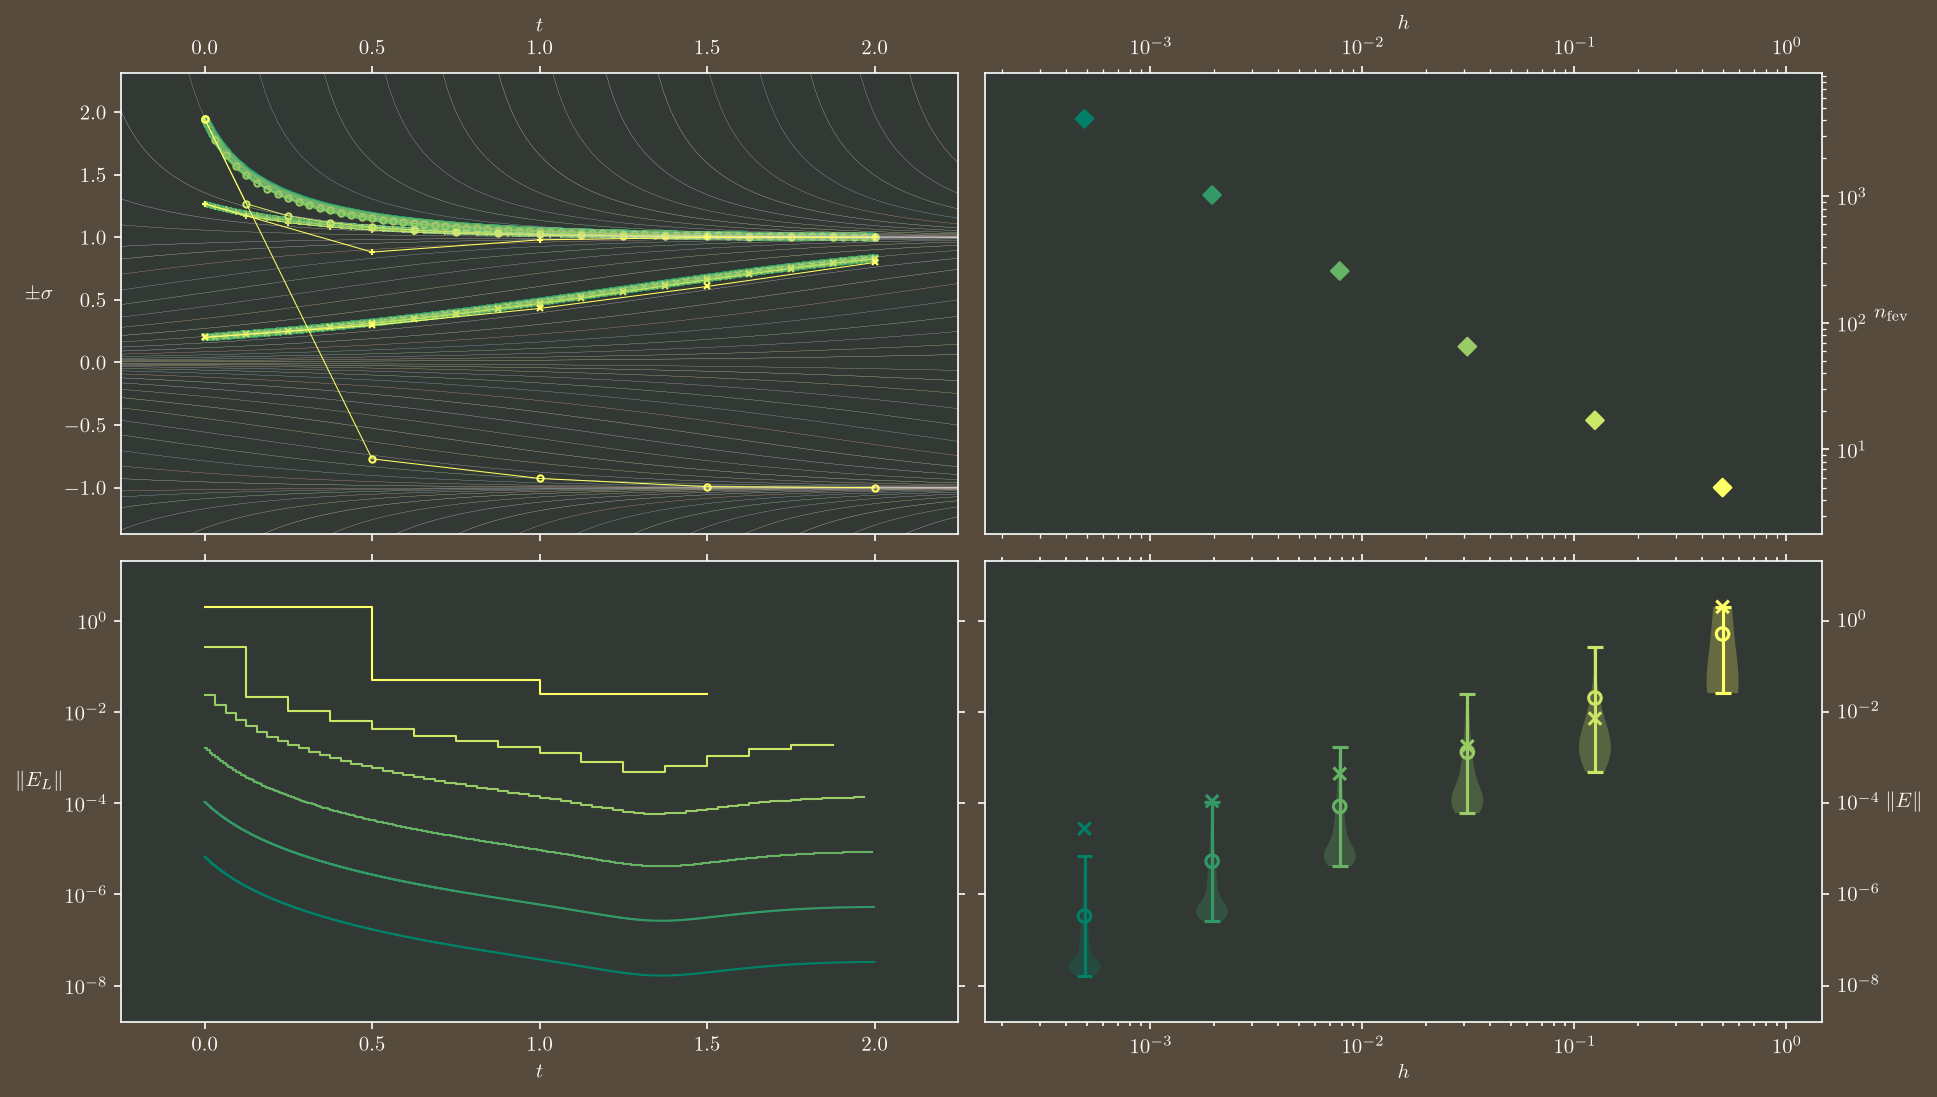

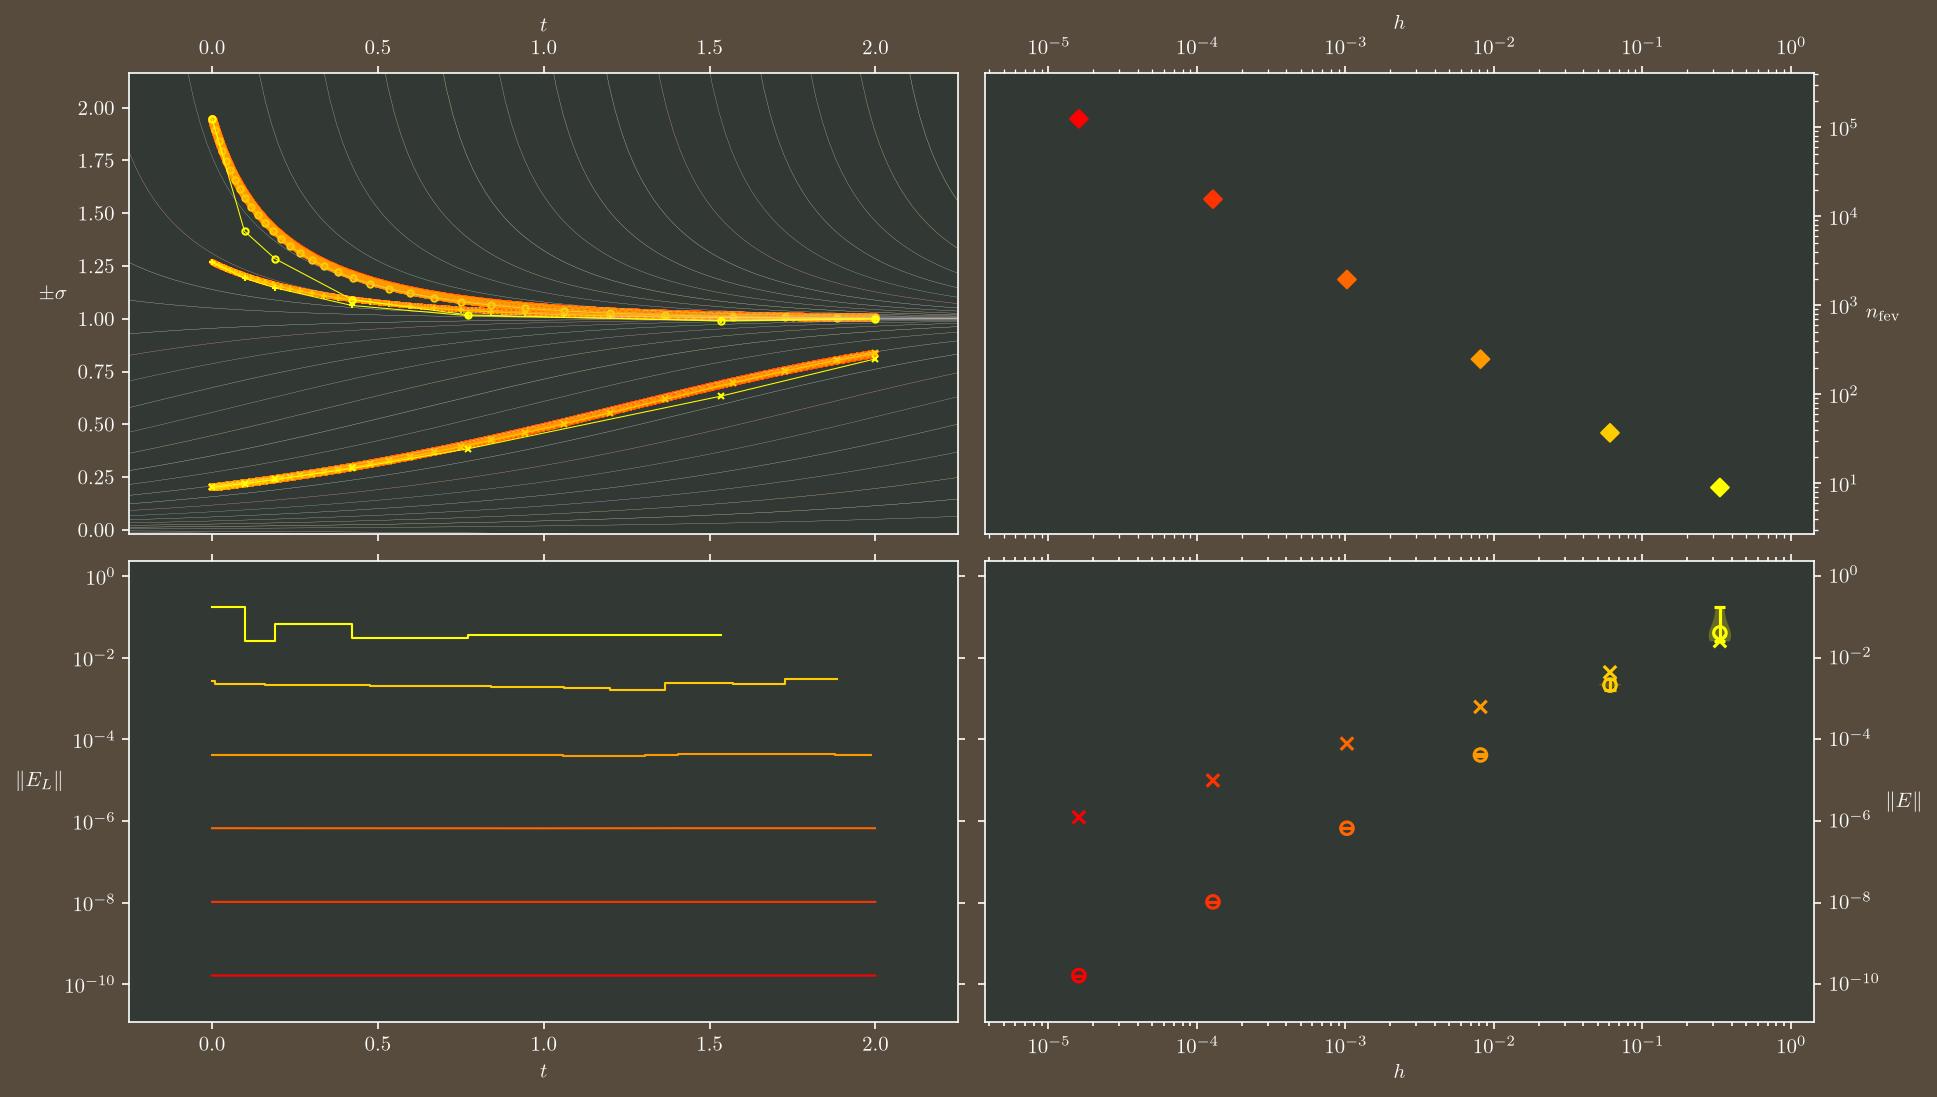

In [24]:
make_error_analysis_figure(naive_rk11_error_analysis_result, mpl.colormaps["summer"])
make_error_analysis_figure(rk11_error_analysis_result, mpl.colormaps["autumn"])

# Just repeat for RK3(2) for now

/tmp/ipykernel_16434/1660277819.py:11: RuntimeWarning: invalid value encountered in sqrt
  np.reciprocal(np.sqrt(determinant)),


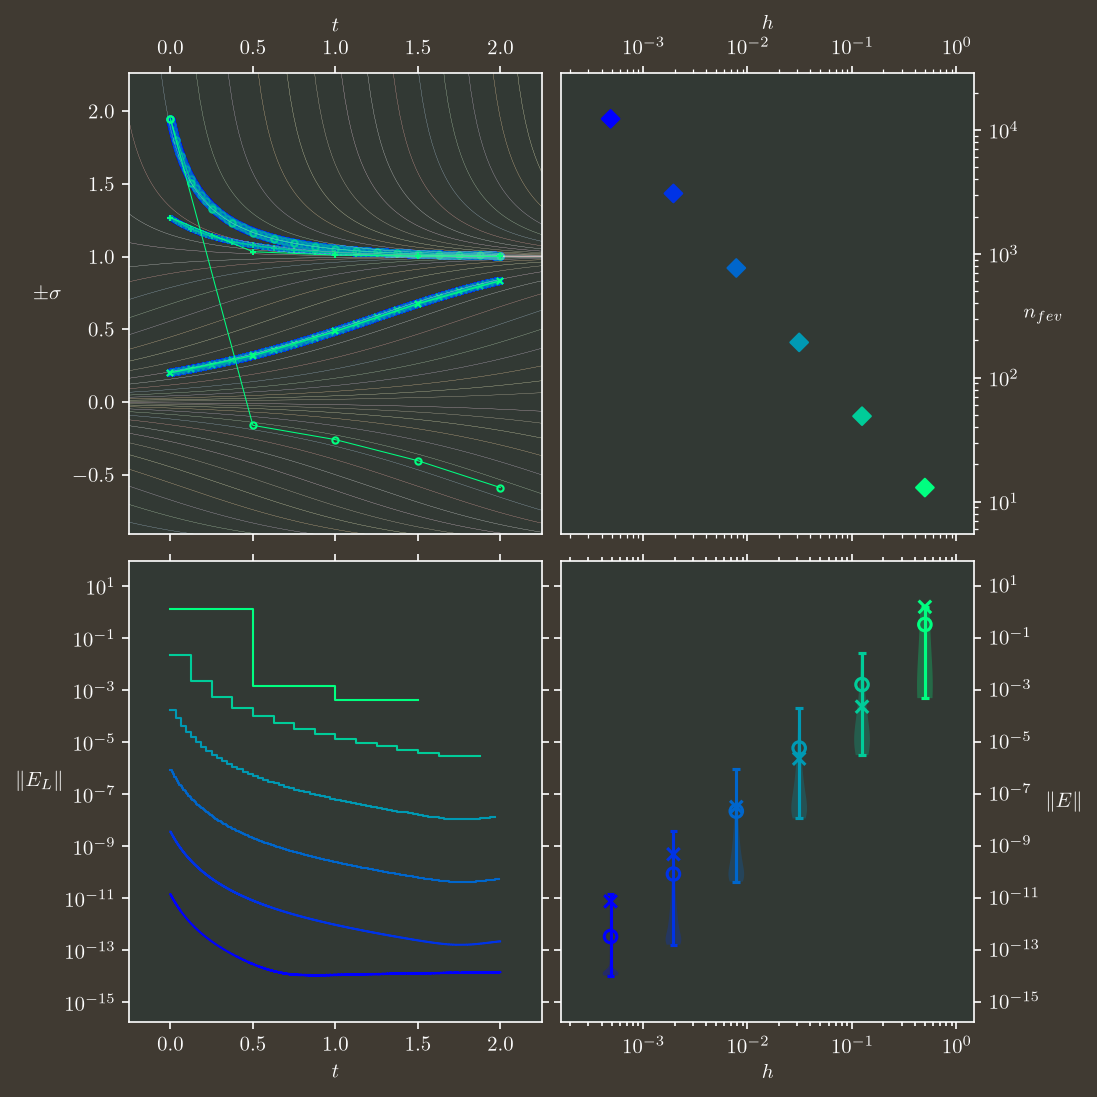

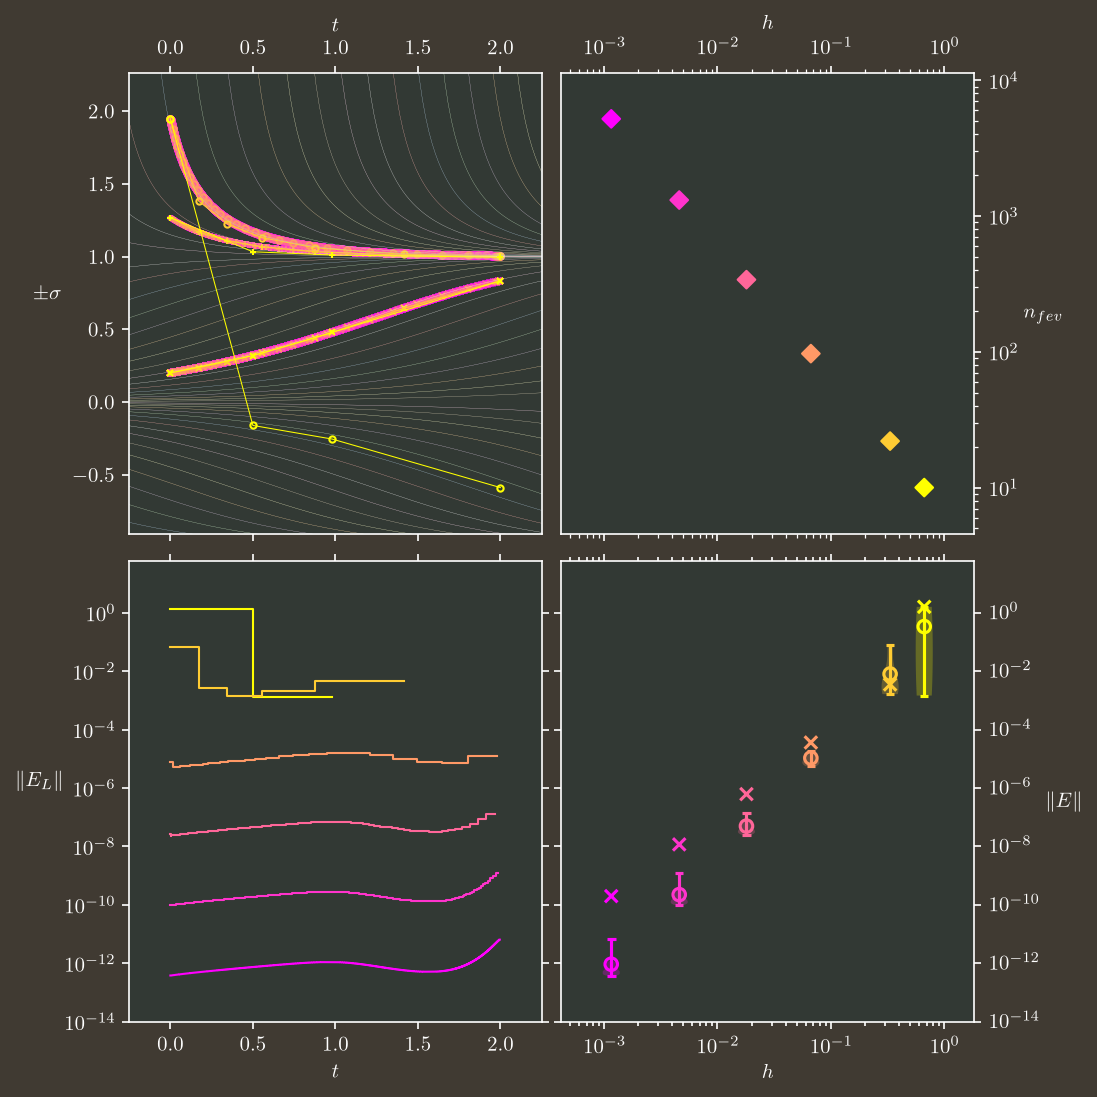

In [18]:
rk23_facecolor = colorsys.hsv_to_rgb(34.6 / 360, 0.302 * 0.75, 0.337 * 0.75)
make_error_analysis_figure(
    naive_rk23_error_analysis_result,
    mpl.colormaps["winter"],
    figkwargs=dict(figsize=7.2 * np.array([1.0, 1.0]), facecolor=rk23_facecolor),
)
make_error_analysis_figure(
    rk23_error_analysis_result,
    mpl.colormaps["spring"],
    figkwargs=dict(figsize=7.2 * np.array([1.0, 1.0]), facecolor=rk23_facecolor),
)

# Try you a Radau

/tmp/ipykernel_16434/1660277819.py:11: RuntimeWarning: invalid value encountered in sqrt
  np.reciprocal(np.sqrt(determinant)),


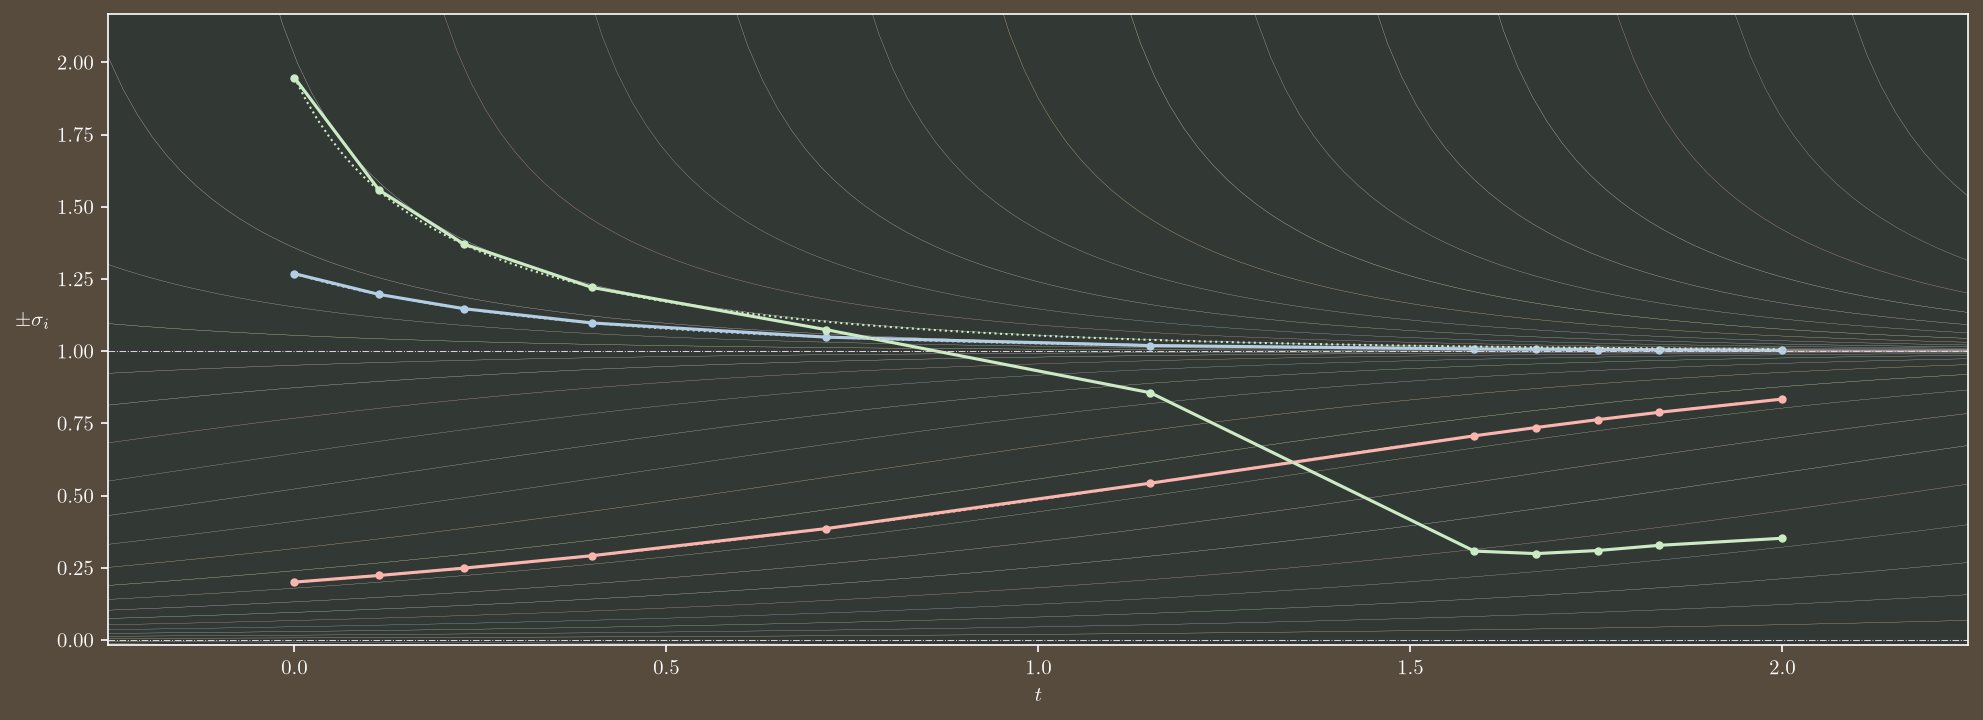

In [19]:
fig: plt.Figure = plt.figure(figsize=plt.figaspect(415 / 1216))
ax: plt.Axes = fig.add_subplot()

ax.set_xlabel("$t$")
ax.set_ylabel("$\\pm\\sigma_i$", labelpad=12, rotation=0)

plot_polygon_of_soln_svs(ax, radau_error_analysis_result.solns[1], U, V)

# ax.set_autoscale_on(False) # I want to do this but it seems buggy???
ax.set_xlim(*ax.get_xlim())
ax.set_ylim(*ax.get_ylim())
plot_flow_lines(ax, 16)

ax.axhline(-1.0, linewidth=0.5, linestyle="-.", color="C3")
ax.axhline(0.0, linewidth=0.5, linestyle="-.", color="C3")
ax.axhline(1.0, linewidth=0.5, linestyle="-.", color="C3")

plt.show()

/tmp/ipykernel_16434/1660277819.py:11: RuntimeWarning: invalid value encountered in sqrt
  np.reciprocal(np.sqrt(determinant)),


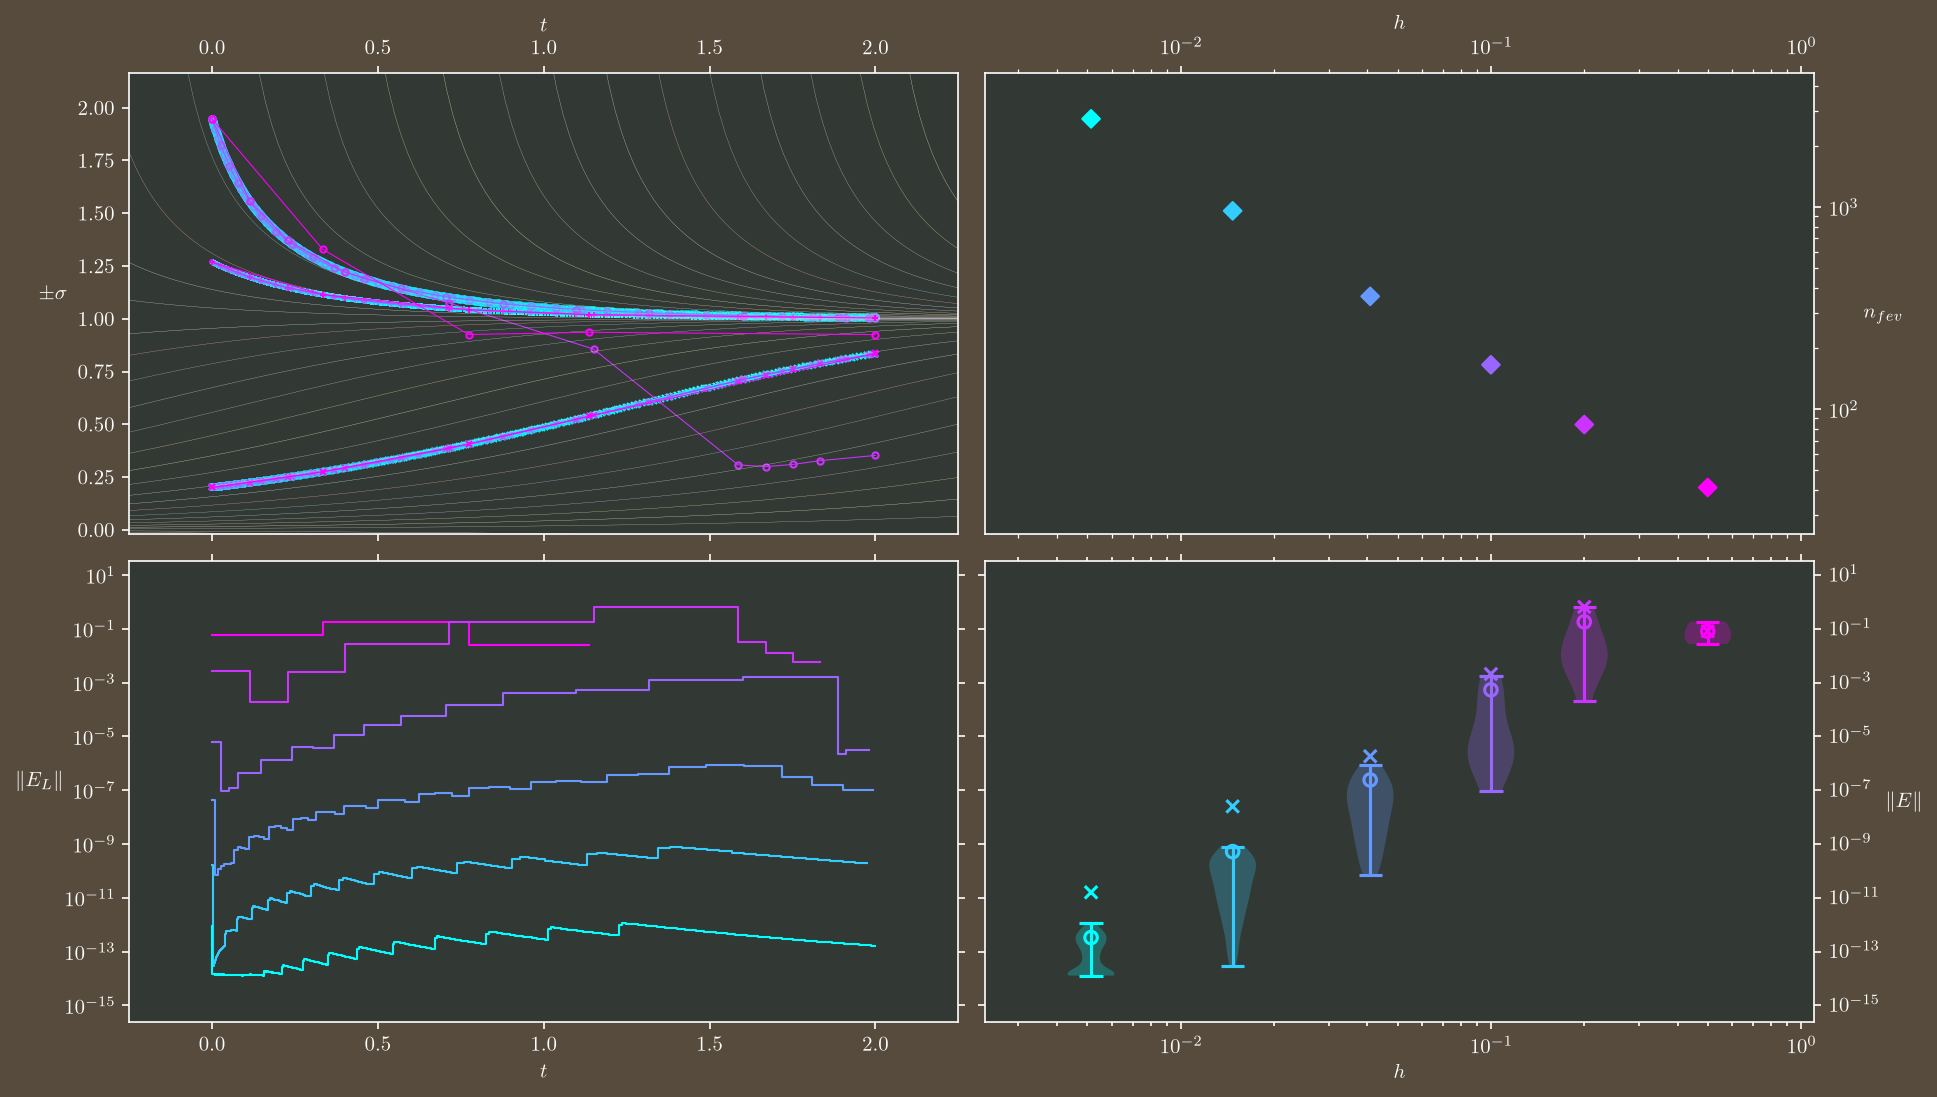

In [20]:
make_error_analysis_figure(radau_error_analysis_result, mpl.colormaps["cool"])

# Work-precision

First get effective function evaluation coefficients:

In [21]:
rng = np.random.default_rng(0xE1E100)
num_random_vecs = 1000
random_vecs = rng.uniform(-2.0, 2.0, size=num_random_vecs * X0.shape[0] * X0.shape[1]).reshape(
    (num_random_vecs, -1)
)
fev_time = sum(timeit.timeit(lambda: polar_factor_flow_fun(0.0, vec), number=10) for vec in random_vecs)
jev_scale = sum(timeit.timeit(lambda: polar_factor_flow_jac(0.0, vec), number=10) for vec in random_vecs) / fev_time
random_jacs = [polar_factor_flow_jac(0.0, vec) for vec in random_vecs]
lu_scale = sum(timeit.timeit(lambda: spla.lu_factor(jac), number=10) for jac in random_jacs) / fev_time
jev_scale, lu_scale

(3.1649903946755646, 1.235564884637892)

Can now make a work-precision diagram:

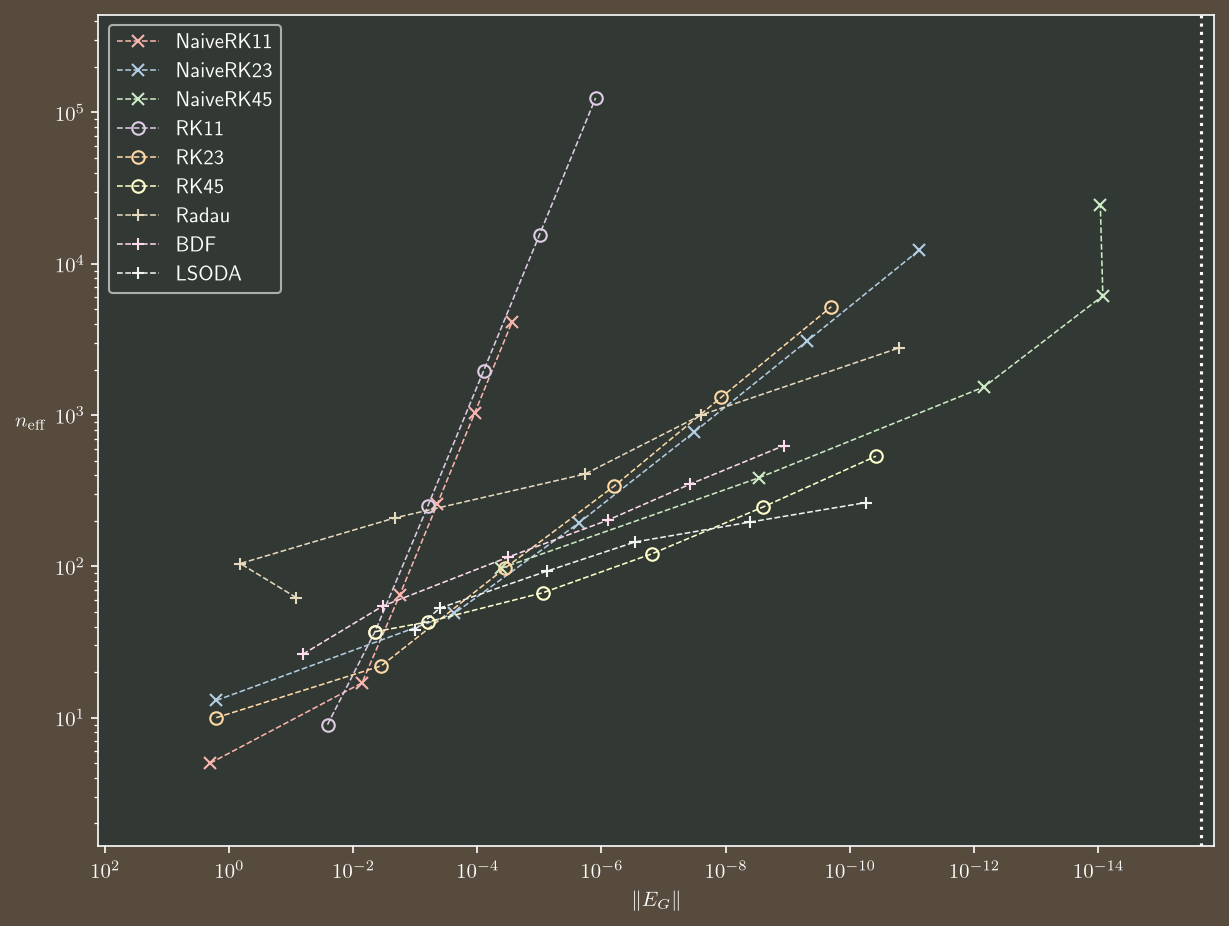

In [22]:
fig, ax = plt.subplots()
ax.set_xlabel("$\\left\\Vert E_G \\right\\Vert$")
ax.set_xscale("log", **log_scale_kwargs)
ax.set_xinverted(True)
ax.set_ylabel("$n_{\\mathrm{eff}}$", labelpad=12, rotation=0)
ax.set_yscale("log", **log_scale_kwargs)

for i, (name, result) in enumerate(error_analyses.items()):
    work = [
        soln.nfev + jev_scale * soln.njev + lu_scale * soln.nlu for soln in result.solns
    ]
    ax.plot(
        result.global_errors,
        work,
        f"--{['x', 'o', '+'][(i // 3) % 3]}",
        linewidth=0.75,
        fillstyle="none",
        label=name,
    )

ax.set_xlim(*ax.get_xlim())
ax.set_ylim(*ax.get_ylim())
ax.axvline(np.finfo(float).eps, zorder=-1, linestyle=":")
ax.legend()